In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
raw_data_full = pd.read_csv("../data/autos.csv")
print(raw_data_full.shape)
raw_data_full.head(10)

(371528, 21)


,index,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,...,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
0,0,2016-03-24 11:52:17,Golf_3_1.6,privat,Angebot,480,test,NaN,1993,manuell,...,golf,150000,0,benzin,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,1,2016-03-24 10:58:45,A5_Sportback_2.7_Tdi,privat,Angebot,18300,test,coupe,2011,manuell,...,NaN,125000,5,diesel,audi,ja,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2,2016-03-14 12:52:21,"Jeep_Grand_Cherokee_""Overland""",privat,Angebot,9800,test,suv,2004,automatik,...,grand,125000,8,diesel,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,3,2016-03-17 16:54:04,GOLF_4_1_4__3TÜRER,privat,Angebot,1500,test,kleinwagen,2001,manuell,...,golf,150000,6,benzin,volkswagen,nein,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,4,2016-03-31 17:25:20,Skoda_Fabia_1.4_TDI_PD_Classic,privat,Angebot,3600,test,kleinwagen,2008,manuell,...,fabia,90000,7,diesel,skoda,nein,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21
5,5,2016-04-04 17:36:23,BMW_316i___e36_Limousine___Bastlerfahrzeug__Ex...,privat,Angebot,650,test,limousine,1995,manuell,...,3er,150000,10,benzin,bmw,ja,2016-04-04 00:00:00,0,33775,2016-04-06 19:17:07
6,6,2016-04-01 20:48:51,Peugeot_206_CC_110_Platinum,privat,Angebot,2200,test,cabrio,2004,manuell,...,2_reihe,150000,8,benzin,peugeot,nein,2016-04-01 00:00:00,0,67112,2016-04-05 18:18:39
7,7,2016-03-21 18:54:38,VW_Derby_Bj_80__Scheunenfund,privat,Angebot,0,test,limousine,1980,manuell,...,andere,40000,7,benzin,volkswagen,nein,2016-03-21 00:00:00,0,19348,2016-03-25 16:47:58
8,8,2016-04-04 23:42:13,Ford_C___Max_Titanium_1_0_L_EcoBoost,privat,Angebot,14500,control,bus,2014,manuell,...,c_max,30000,8,benzin,ford,NaN,2016-04-04 00:00:00,0,94505,2016-04-04 23:42:13
9,9,2016-03-17 10:53:50,VW_Golf_4_5_tuerig_zu_verkaufen_mit_Anhaengerk...,privat,Angebot,999,test,kleinwagen,1998,manuell,...,golf,150000,0,NaN,volkswagen,NaN,2016-03-17 00:00:00,0,27472,2016-03-31 17:17:06


In [3]:
# list all columns
print(raw_data_full.columns.values)

['index' 'dateCrawled' 'name' 'seller' 'offerType' 'price' 'abtest'
 'vehicleType' 'yearOfRegistration' 'gearbox' 'powerPS' 'model'
 'kilometer' 'monthOfRegistration' 'fuelType' 'brand' 'notRepairedDamage'
 'dateCreated' 'nrOfPictures' 'postalCode' 'lastSeen']


In [4]:
print(raw_data_full["dateCrawled"].min())
print(raw_data_full["dateCrawled"].max())

2016-03-05 14:06:22
2016-04-07 14:36:58


In [5]:
# select only the columns of interest
columns_of_interest = ['seller', 'vehicleType', 'yearOfRegistration', 'gearbox', 'powerPS', 'kilometer', 'fuelType', 'brand', 'price']
raw_data = raw_data_full[columns_of_interest]
raw_data.head(10)

,seller,vehicleType,yearOfRegistration,gearbox,powerPS,kilometer,fuelType,brand,price
0,privat,NaN,1993,manuell,0,150000,benzin,volkswagen,480
1,privat,coupe,2011,manuell,190,125000,diesel,audi,18300
2,privat,suv,2004,automatik,163,125000,diesel,jeep,9800
3,privat,kleinwagen,2001,manuell,75,150000,benzin,volkswagen,1500
4,privat,kleinwagen,2008,manuell,69,90000,diesel,skoda,3600
5,privat,limousine,1995,manuell,102,150000,benzin,bmw,650
6,privat,cabrio,2004,manuell,109,150000,benzin,peugeot,2200
7,privat,limousine,1980,manuell,50,40000,benzin,volkswagen,0
8,privat,bus,2014,manuell,125,30000,benzin,ford,14500
9,privat,kleinwagen,1998,manuell,101,150000,NaN,volkswagen,999


In [6]:
print(f"Shape of the dataset: {raw_data.shape}")
print(raw_data.info())

Shape of the dataset: (371528, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371528 entries, 0 to 371527
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   seller              371528 non-null  object
 1   vehicleType         333659 non-null  object
 2   yearOfRegistration  371528 non-null  int64 
 3   gearbox             351319 non-null  object
 4   powerPS             371528 non-null  int64 
 5   kilometer           371528 non-null  int64 
 6   fuelType            338142 non-null  object
 7   brand               371528 non-null  object
 8   price               371528 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 25.5+ MB
None


In [7]:
# count categorical cols, numerical cols and date cols
categorical_cols = raw_data.select_dtypes(exclude="number").columns
numerical_cols = raw_data.select_dtypes(include="number").columns
print("Categorical columns:", len(categorical_cols))
print("Numerical columns:", len(numerical_cols))
missing_values = raw_data.isnull().sum()
print("Total missing values in the dataset:", missing_values.sum())



Categorical columns: 5
Numerical columns: 4
Total missing values in the dataset: 91464


In [8]:
numerical_cols_ = raw_data[["powerPS", "yearOfRegistration", "kilometer"]]
for col in numerical_cols_:
    print(f"Summary statistics for {col}:")
    print(raw_data[col].describe())
    print("\n")

Summary statistics for powerPS:
count    371528.000000
mean        115.549477
std         192.139578
min           0.000000
25%          70.000000
50%         105.000000
75%         150.000000
max       20000.000000
Name: powerPS, dtype: float64


Summary statistics for yearOfRegistration:
count    371528.000000
mean       2004.577997
std          92.866598
min        1000.000000
25%        1999.000000
50%        2003.000000
75%        2008.000000
max        9999.000000
Name: yearOfRegistration, dtype: float64


Summary statistics for kilometer:
count    371528.000000
mean     125618.688228
std       40112.337051
min        5000.000000
25%      125000.000000
50%      150000.000000
75%      150000.000000
max      150000.000000
Name: kilometer, dtype: float64




In [9]:
# exploring price col
print("Price column info:")
print(raw_data["price"].describe())

Price column info:
count    3.715280e+05
mean     1.729514e+04
std      3.587954e+06
min      0.000000e+00
25%      1.150000e+03
50%      2.950000e+03
75%      7.200000e+03
max      2.147484e+09
Name: price, dtype: float64


In [10]:
categorical_cols_ = raw_data.select_dtypes(exclude="number")
for col in categorical_cols_:
    if col == "name": continue
    print(f"\nCategories values in {col}:\n{raw_data[col].value_counts()}")
    print("\npercentage of each category:")
    print((raw_data[col].value_counts() * 100 / len(raw_data)).round(2))


Categories values in seller:
seller
privat        371525
gewerblich         3
Name: count, dtype: int64

percentage of each category:
seller
privat        100.0
gewerblich      0.0
Name: count, dtype: float64

Categories values in vehicleType:
vehicleType
limousine     95894
kleinwagen    80023
kombi         67564
bus           30201
cabrio        22898
coupe         19015
suv           14707
andere         3357
Name: count, dtype: int64

percentage of each category:
vehicleType
limousine     25.81
kleinwagen    21.54
kombi         18.19
bus            8.13
cabrio         6.16
coupe          5.12
suv            3.96
andere         0.90
Name: count, dtype: float64

Categories values in gearbox:
gearbox
manuell      274214
automatik     77105
Name: count, dtype: int64

percentage of each category:
gearbox
manuell      73.81
automatik    20.75
Name: count, dtype: float64

Categories values in fuelType:
fuelType
benzin     223857
diesel     107746
lpg          5378
cng           571
hybri

In [26]:
# defining the threshold for the price tiers
price_thresholds = [0, 15000, 35000, float("inf")]
price_labels = ["budget", "mid-range", "luxury"]
# creating a new column for price tiers
raw_data["price_tier"] = pd.cut(raw_data["price"], bins=price_thresholds, labels=price_labels)
print(raw_data["price_tier"].value_counts())
print((raw_data["price_tier"].value_counts()/len(raw_data["price_tier"]) * 100).round(2), "%")
# print(raw_data_no_outliers[["price", "price_tier"]].head())

price_tier
budget       328723
mid-range     28050
luxury         3977
Name: count, dtype: int64
price_tier
budget       88.48
mid-range     7.55
luxury        1.07
Name: count, dtype: float64 %


/tmp/ipykernel_279640/2278106155.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_data["price_tier"] = pd.cut(raw_data["price"], bins=price_thresholds, labels=price_labels)


In [27]:
# checking for missing values
missing_values = raw_data.isnull().sum()

print("Total missing values in the dataset:", missing_values.sum())
print("Missing values in each column:")
print(f"{missing_values[missing_values > 0]}")
print(f"{(missing_values[missing_values > 0] * 100 / len(raw_data)).round(2)}")

Total missing values in the dataset: 102242
Missing values in each column:
vehicleType    37869
gearbox        20209
fuelType       33386
price_tier     10778
dtype: int64
vehicleType    10.19
gearbox         5.44
fuelType        8.99
price_tier      2.90
dtype: float64


In [28]:
# checking for full-duplicates rows
duplicate_rows = raw_data[raw_data.duplicated()]
print("Number of duplicate rows:", duplicate_rows.shape[0])


Number of duplicate rows: 67134


In [29]:
raw_data.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
371523    False
371524    False
371525    False
371526    False
371527    False
Length: 371528, dtype: bool

In [30]:
print(raw_data["yearOfRegistration"].describe())
print(raw_data["yearOfRegistration"].skew())

count    371528.000000
mean       2004.577997
std          92.866598
min        1000.000000
25%        1999.000000
50%        2003.000000
75%        2008.000000
max        9999.000000
Name: yearOfRegistration, dtype: float64
72.13364168417992


In [31]:
print(raw_data["powerPS"].describe())

count    371528.000000
mean        115.549477
std         192.139578
min           0.000000
25%          70.000000
50%         105.000000
75%         150.000000
max       20000.000000
Name: powerPS, dtype: float64


In [32]:
# Data Validity Checks
print("Check for invalid powerPS values (<= 0) or (>= 5000):")
print(raw_data[raw_data['powerPS']<=0]["powerPS"].count())
print(raw_data[raw_data['powerPS']>=5000]["powerPS"].count())
print(f"Total invalid powerPS values: {(raw_data[raw_data['powerPS']<=0]['powerPS'].count() + raw_data[raw_data['powerPS']>=5000]['powerPS'].count())}")
print(f"percentage of invalid powerPS values: {((raw_data[raw_data['powerPS']<=0]['powerPS'].count() + raw_data[raw_data['powerPS']>=5000]['powerPS'].count()) * 100 / len(raw_data)).round(2)}% ")

print("Check for invalid kilometer values (< 0) or (> 300000):")
print(raw_data[raw_data['kilometer']<0]["kilometer"].count())
print(raw_data[raw_data['kilometer']>300000]["kilometer"].count())
print(f"Total invalid kilometer values: {(raw_data[raw_data['kilometer']<0]['kilometer'].count() + raw_data[raw_data['kilometer']>300000]['kilometer'].count())}")
print(f"percentage of invalid kilometer values: {((raw_data[raw_data['kilometer']<0]['kilometer'].count() + raw_data[raw_data['kilometer']>300000]['kilometer'].count()) * 100 / len(raw_data)).round(2)}% ")

print("Check for invalid yearOfRegistration values (< 1900):")
print(raw_data[raw_data['yearOfRegistration']<1900]["yearOfRegistration"].count())
print(f"Total invalid yearOfRegistration values: {raw_data[raw_data['yearOfRegistration']<1900]['yearOfRegistration'].count()}")
print("Check for invalid yearOfRegistration values (> 2023):")
print(raw_data[raw_data['yearOfRegistration']>2023]["yearOfRegistration"].count())
print(f"Total invalid yearOfRegistration values: {raw_data[raw_data['yearOfRegistration']>2023]['yearOfRegistration'].count()+raw_data[raw_data['yearOfRegistration']<1900]['yearOfRegistration'].count()}")
print(f"percentage of invalid yearOfRegistration values: {((raw_data[raw_data['yearOfRegistration']>2023]['yearOfRegistration'].count()+raw_data[raw_data['yearOfRegistration']<1900]['yearOfRegistration'].count()) * 100 / len(raw_data)).round(2)}% ")


Check for invalid powerPS values (<= 0) or (>= 5000):
40820
87
Total invalid powerPS values: 40907
percentage of invalid powerPS values: 11.01% 
Check for invalid kilometer values (< 0) or (> 300000):
0
0
Total invalid kilometer values: 0
percentage of invalid kilometer values: 0.0% 
Check for invalid yearOfRegistration values (< 1900):
68
Total invalid yearOfRegistration values: 68
Check for invalid yearOfRegistration values (> 2023):
114
Total invalid yearOfRegistration values: 182
percentage of invalid yearOfRegistration values: 0.05% 


In [33]:
print("Check for invalid price values (< 0):")
print(raw_data[raw_data['price']<0]["price"].count())
print(f"Total invalid price values: {raw_data[raw_data['price']<0]['price'].count()}")
print(f"percentage of invalid price values: {((raw_data[raw_data['price']<0]['price'].count()) * 100 / len(raw_data)).round(2)}% ")


Check for invalid price values (< 0):
0
Total invalid price values: 0
percentage of invalid price values: 0.0% 


In [34]:
# removing outliers from price col using IQR method
print(raw_data["price"].describe())
Q1 = raw_data["price"].quantile(0.25)
Q3 = raw_data["price"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
raw_data_outliers = raw_data[(raw_data["price"] < lower_bound) | (raw_data["price"] > upper_bound)]
raw_data_no_outliers = raw_data[(raw_data["price"] >= lower_bound) & (raw_data["price"] <= upper_bound)]
print("Number of outliers in price column:", raw_data_outliers.shape[0])
print("Percentage of outliers in price column:", (raw_data_outliers.shape[0] / len(raw_data)) * 100)


count    3.715280e+05
mean     1.729514e+04
std      3.587954e+06
min      0.000000e+00
25%      1.150000e+03
50%      2.950000e+03
75%      7.200000e+03
max      2.147484e+09
Name: price, dtype: float64
Number of outliers in price column: 28108
Percentage of outliers in price column: 7.565513231842553


In [35]:
# Outliers in kilometer col using IQR method
print(raw_data["kilometer"].describe())
Q1_km = raw_data["kilometer"].quantile(0.25)
Q3_km = raw_data["kilometer"].quantile(0.75)
IQR_km = Q3_km - Q1_km
lower_bound_km = Q1_km - 1.5 * IQR_km
upper_bound_km = Q3_km + 1.5 * IQR_km
raw_data_km_outliers = raw_data[(raw_data["kilometer"] < lower_bound_km) | (raw_data["kilometer"] > upper_bound_km)]
raw_data_km_no_outliers = raw_data[(raw_data["kilometer"] >= lower_bound_km) & (raw_data["kilometer"] <= upper_bound_km)]
print("Number of outliers in kilometer column:", raw_data_km_outliers.shape[0])
print("Percentage of outliers in kilometer column:", (raw_data_km_outliers.shape[0] / len(raw_data)) * 100) 

count    371528.000000
mean     125618.688228
std       40112.337051
min        5000.000000
25%      125000.000000
50%      150000.000000
75%      150000.000000
max      150000.000000
Name: kilometer, dtype: float64
Number of outliers in kilometer column: 64221
Percentage of outliers in kilometer column: 17.28564199737301


In [36]:
# Skewness
print("Skewness of price column:", raw_data["price"].skew())
print("Skewness of kilometer column:", raw_data["kilometer"].skew())
print("Skewness of power column:", raw_data["powerPS"].skew())
print("Skewness of registration year column:", raw_data["yearOfRegistration"].skew())

Skewness of price column: 578.0590836551854
Skewness of kilometer column: -1.5515772692054193
Skewness of power column: 58.199908725207486
Skewness of registration year column: 72.13364168417992


In [37]:
# Checking Consistency - Schema & Data Types
print("Data Types of Each Column:")
print(raw_data.dtypes)


Data Types of Each Column:
seller                  object
vehicleType             object
yearOfRegistration       int64
gearbox                 object
powerPS                  int64
kilometer                int64
fuelType                object
brand                   object
price                    int64
price_tier            category
dtype: object


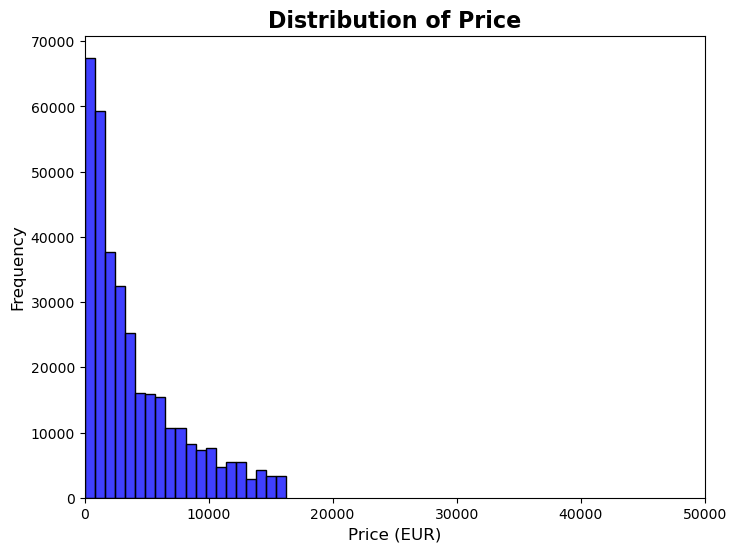

In [38]:
# visualizing the distribution of price tiers
plt.figure(figsize=(8, 6))
sns.histplot(raw_data_no_outliers["price"], bins=20, color="blue")
plt.title("Distribution of Price", fontsize=16, fontweight='bold')
plt.xlabel("Price (EUR)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xlim(0, 50000)
plt.savefig("../reports/price_distribution.png")
plt.show()

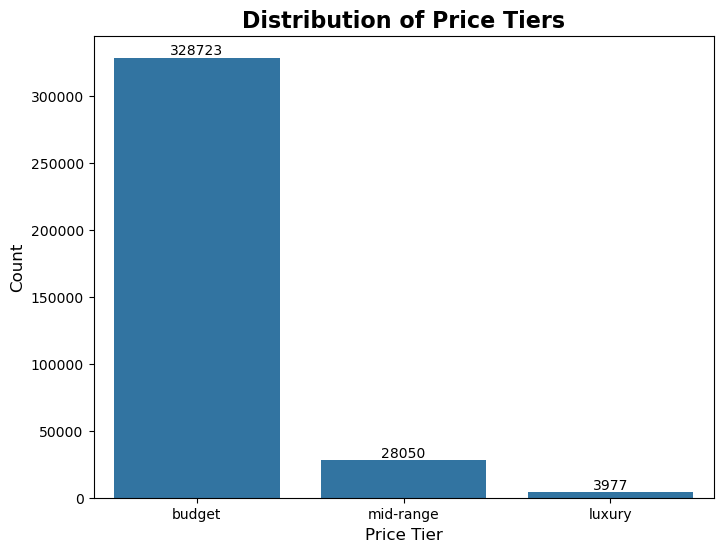

In [39]:
plt.figure(figsize=(8, 6))
sns.countplot(x="price_tier", data=raw_data)
plt.title("Distribution of Price Tiers", fontsize=16, fontweight='bold')
plt.xlabel("Price Tier", fontsize=12)
plt.ylabel("Count", fontsize=12)
for index, value in enumerate(raw_data["price_tier"].value_counts()):
    plt.text(index, value, str(value), ha='center', va='bottom')
plt.savefig("../reports/price_tier_distribution.png")
plt.show()

In [40]:
raw_data.head()

,seller,vehicleType,yearOfRegistration,gearbox,powerPS,kilometer,fuelType,brand,price,price_tier
0,privat,NaN,1993,manuell,0,150000,benzin,volkswagen,480,budget
1,privat,coupe,2011,manuell,190,125000,diesel,audi,18300,mid-range
2,privat,suv,2004,automatik,163,125000,diesel,jeep,9800,budget
3,privat,kleinwagen,2001,manuell,75,150000,benzin,volkswagen,1500,budget
4,privat,kleinwagen,2008,manuell,69,90000,diesel,skoda,3600,budget


In [42]:
raw_data.to_csv("../data/kaggle_dataset_features.csv", index=False)